🎨 正在读取数据并渲染...
✅ HTML 已保存: polymer_kg_final.html
📸 正在启动后台浏览器截取 PNG，请稍候...
✅ PNG 已保存: polymer_kg_final.png


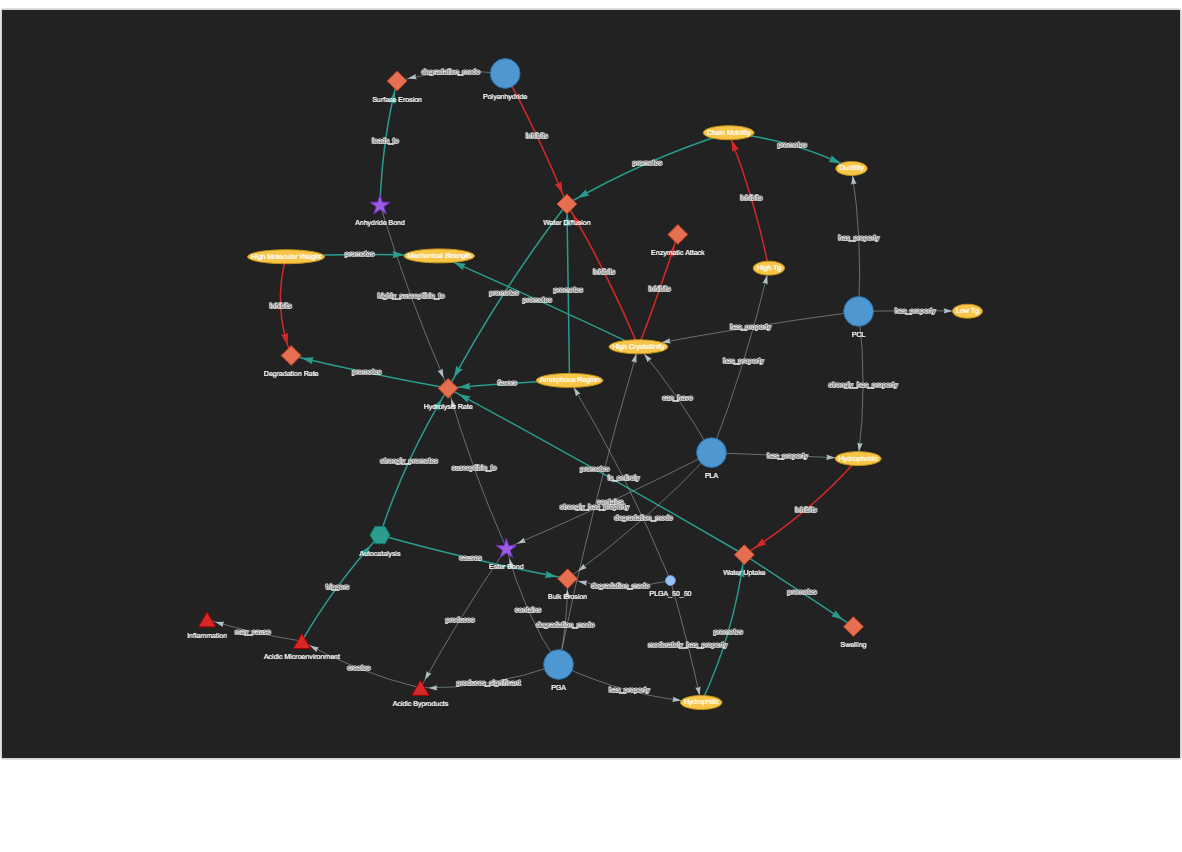

In [1]:
# Agent/Quality_loop/kg_visualizer.ipynb

import json
import os
import time
from pyvis.network import Network
from IPython.display import display, IFrame, Image

# 尝试导入 Selenium 相关库用于 PNG截图
try:
    from selenium import webdriver
    from selenium.webdriver.chrome.options import Options
    from selenium.webdriver.chrome.service import Service
    from webdriver_manager.chrome import ChromeDriverManager
    SELENIUM_AVAILABLE = True
except ImportError:
    SELENIUM_AVAILABLE = False
    print("⚠️ 未检测到 Selenium。PNG 保存功能将不可用。如需使用，请运行: pip install selenium webdriver-manager")

class KGVisualizer:
    def __init__(self, json_path="loop_knowledge_base.json"):
        self.json_path = json_path
        # 自动检测路径逻辑 (保持不变)
        if not os.path.exists(self.json_path):
            alt_path = os.path.join("Agent", "Quality_loop", "loop_knowledge_base.json")
            if os.path.exists(alt_path):
                self.json_path = alt_path
            elif os.path.exists(os.path.basename(json_path)):
                 self.json_path = os.path.basename(json_path)

        self.data = self._load_data()

    def _load_data(self):
        if not os.path.exists(self.json_path):
            raise FileNotFoundError(f"❌ 找不到知识库文件: {self.json_path} (请确认文件路径)")
        
        with open(self.json_path, 'r', encoding='utf-8') as f:
            return json.load(f)

    def _get_node_style(self, node_type):
        # (样式保持不变)
        style_map = {
            "Material": {"color": "#4E97D1", "shape": "dot", "size": 30},
            "Property": {"color": "#F7C548", "shape": "ellipse", "size": 20},
            "Process":  {"color": "#E76F51", "shape": "diamond", "size": 20},
            "Outcome":  {"color": "#D62828", "shape": "triangle", "size": 15},
            "Mechanism":{"color": "#2A9D8F", "shape": "hexagon", "size": 20},
            "Chemical Bond": {"color": "#9B5DE5", "shape": "star", "size": 20}
        }
        return style_map.get(node_type, {"color": "#97C2FC", "shape": "dot", "size": 10})

    # 🔥 修改这个函数来调整连线颜色和粗细
    def _get_edge_style(self, relation):
        """
        返回: (颜色代码, 线条宽度)
        """
        relation = relation.lower()
        
        # 负面关系关键词
        negatives = ["inhibits", "reduces", "conflicts_with", "prevents", "inhibits_entry"]
        # 正面关系关键词
        positives = ["promotes", "leads_to", "favors", "triggers", "causes", "strongly_promotes"]
        
        if any(x in relation for x in negatives):
            # 🔴 抑制：使用砖红色 (适合论文)
            # 宽度设为 3
            return "#D62828", 3  
            
        elif any(x in relation for x in positives):
            # 🔵 促进：使用青蓝色 (与红色对比明显，且不刺眼)
            # 宽度设为 3
            return "#2A9D8F", 3  
            
        else:
            # ⚪ 普通关系：浅灰色，尽量不抢眼
            # 宽度设为 1 (最细)
            return "#B0BEC5", 1

    # 🔥🔥🔥 新增方法: 使用 Selenium 将 HTML 转为 PNG 🔥🔥🔥
    def _save_html_to_png(self, html_path, png_path):
        if not SELENIUM_AVAILABLE:
            print("⚠️ 跳过 PNG 保存 (缺少 Selenium)。")
            return

        print(f"📸 正在启动后台浏览器截取 PNG，请稍候...")
        try:
            chrome_options = Options()
            chrome_options.add_argument("--headless") # 无头模式，不显示浏览器窗口
            chrome_options.add_argument("--window-size=1200,1000") # 设置截图分辨率
            # 禁用 GPU 加速可能提高在某些环境下的稳定性
            chrome_options.add_argument("--disable-gpu") 
            # 解决部分 Linux 环境下的权限问题
            chrome_options.add_argument("--no-sandbox")

            # 自动安装/查找 ChromeDriver
            service = Service(ChromeDriverManager().install())
            driver = webdriver.Chrome(service=service, options=chrome_options)

            # 获取 HTML 文件的绝对路径
            abs_html_path = os.path.abspath(html_path)
            # 使用 file:/// 协议在浏览器中打开本地文件
            driver.get(f"file:///{abs_html_path}")

            # ⏳ 关键: 等待几秒钟，让 JS 渲染完成且物理引擎稳定下来
            time.sleep(3) 

            driver.save_screenshot(png_path)
            driver.quit()
            print(f"✅ PNG 已保存: {png_path}")
            # 在 Notebook 中显示 PNG
            display(Image(filename=png_path))

        except Exception as e:
            print(f"❌ PNG 保存失败: {e}")
            print("提示: 如果是第一次运行，可能需要联网下载 ChromeDriver。")


    def render(self, output_html="polymer_kg.html", output_png="polymer_kg.png"):
        print(f"🎨 正在读取数据并渲染...")
        
        # 1. 初始化
        net = Network(
            height="750px", width="100%", bgcolor="#222222", font_color="white", 
            directed=True, notebook=True, cdn_resources='in_line'
        )
        
        # 2. 填充节点 (保持不变)
        nodes = self.data.get("nodes", [])
        for node in nodes:
            style = self._get_node_style(node.get("type", "Unknown"))
            title_text = f"Type: {node.get('type')}\nAlias: {node.get('alias', '')}\nParams: {node.get('properties', '')}"
            net.add_node(node["id"], label=node["id"], title=title_text, **style)

        # 3. 填充连线 (应用新的样式逻辑)
        links = self.data.get("links", [])
        for link in links:
            # 🔥 获取颜色和宽度
            color, width = self._get_edge_style(link["relation"])
            net.add_edge(
                link["source"], 
                link["target"], 
                title=link["relation"], 
                label=link["relation"], 
                color=color,
                width=width # 🔥 设置宽度
            )

        # 4. 物理引擎配置
        net.force_atlas_2based(gravity=-60, central_gravity=0.005, spring_length=120, spring_strength=0.08)
        
        # 5. 保存流程
        try:
            # 生成并手动保存 UTF-8 HTML
            html_content = net.generate_html()
            with open(output_html, "w", encoding="utf-8") as f:
                f.write(html_content)
            print(f"✅ HTML 已保存: {output_html}")
            
            # 在 Notebook 显示交互式 HTML
            # display(IFrame(src=output_html, width='100%', height='800px'))

            # 🔥 调用 PNG 保存流程
            self._save_html_to_png(output_html, output_png)
            
        except Exception as e:
            print(f"❌ 渲染失败: {e}")

# --- 执行代码 ---
try:
    # 确保已经运行过: pip install selenium webdriver-manager
    viz = KGVisualizer("loop_knowledge_base.json") 
    # 同时指定 html 和 png 的文件名
    viz.render(output_html="polymer_kg_final.html", output_png="polymer_kg_final.png")
except Exception as e:
    print(e)